<a href="https://colab.research.google.com/github/DroidEverything/DroidEverything/blob/main/IPL_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Winning by Runs vs. Wickets: A longitudinal study on the evolution of team strategies and margin of victory over all the seasons from 2008-2022.

Our focus parameters (Season, WonBy, Margin and TossDecision)

In [1]:
# important data analysis imports that we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting style for proper graphs
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Loading the dataset
df = pd.read_csv("/content/drive/MyDrive/MATH_6_IPL_ANALYSIS/IPL_Matches_2008_2022-2.csv")

# View the first few rows
display(df.head())

# Check data types and missing values
df.info()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

Data Cleaning and Preprocessing.

We will exclude matches where there was no standard result.

Example Cases:(washed out, Super Overs etc)

We are determining the cases according to the df.info() output.

In [3]:
# 1. We are dropping where WinningTeam is null
clean_df = df.dropna(subset=['WinningTeam']).copy()

# 2. We will also clean Tied matches / Super Overs
# (Because they don't have standard margins)
clean_df = clean_df[clean_df['SuperOver'] != 'Y']

# 3. We will also clean Rain-affected matches to keep our margin data pure
clean_df = clean_df[clean_df['method'].isna()]

# 4. We will also clean any remaining rows where Margin still might be missing
clean_df = clean_df.dropna(subset=['Margin'])

# 5. We will then format Season column as string for clean grouping in the next steps
clean_df['Season'] = clean_df['Season'].astype(str)

print(f"Original matches: {len(df)}")
print(f"Cleaned matches ready for margin analysis: {len(clean_df)}")

Original matches: 950
Cleaned matches ready for margin analysis: 913


Standardizing process, In historical IPL datasets, early seasons are sometimes recorded weirdly for example "2007/08" instead of "2008".

This can make graphs look messy and out of order.

We will fix this in this step

In [4]:
# We will check the unique values in the Season column
print("Unique seasons before fixing:")
print(clean_df['Season'].unique())

# Then we will standardize the strings
# (if our dataset has '2020/21', '2009/10' or something like this)
# We will keep the first 4 characters (the year) to keep it clean
clean_df['Season'] = clean_df['Season'].apply(lambda x: str(x)[:4])

# Then we will sort the dataset chronologically
clean_df = clean_df.sort_values(by='Season')

print("\nUnique seasons after fixing:")
print(clean_df['Season'].unique())

Unique seasons before fixing:
['2022' '2021' '2020/21' '2019' '2018' '2017' '2016' '2015' '2014' '2013'
 '2012' '2011' '2009/10' '2009' '2007/08']

Unique seasons after fixing:
['2007' '2009' '2011' '2012' '2013' '2014' '2015' '2016' '2017' '2018'
 '2019' '2020' '2021' '2022']


It seems that there were issues before standardizing our dataset.

For example '2020/21' '2007/08' would make our graphs look messy.

So the standardization process was worth it.

Now that our dataset is clean we can plot a piechart.

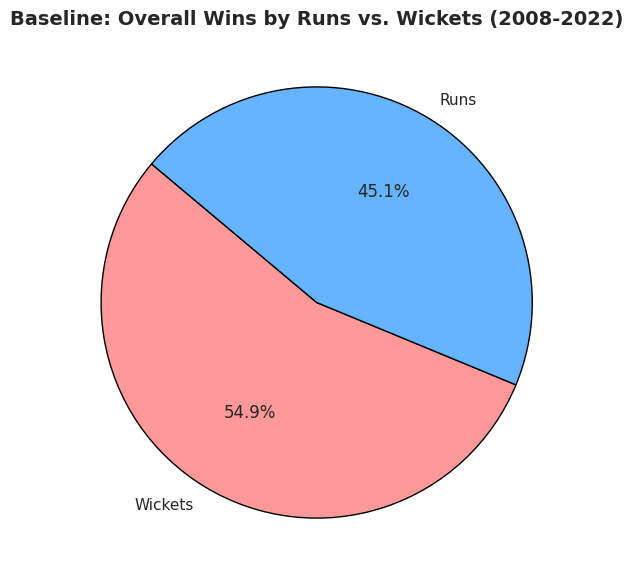

WonBy
Wickets    501
Runs       412
Name: count, dtype: int64


In [5]:
# we will use matplotlib.pyplot, we imported it in the beginning

# We will count the occurrences of (Runs vs Wickets)
# Safety Step: Sometimes there are spaces in the CSV files, so we remove the spaces for safety
clean_df['WonBy'] = clean_df['WonBy'].str.strip()

overall_wins = clean_df['WonBy'].value_counts()

# The chart plotting
plt.figure(figsize=(7, 7))
plt.pie(overall_wins, labels=overall_wins.index, autopct='%1.1f%%',
        colors=['#FF9999', '#66B3FF'], startangle=140,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Baseline: Overall Wins by Runs vs. Wickets (2008-2022)', fontsize=14, fontweight='bold')
plt.show()

print(overall_wins)

Now we will check if chasing Wickets has become more dominant over the years as T20 strategies evolved.

We will create a 100% stacked bar chart to see the proportion of win methods for every single season.

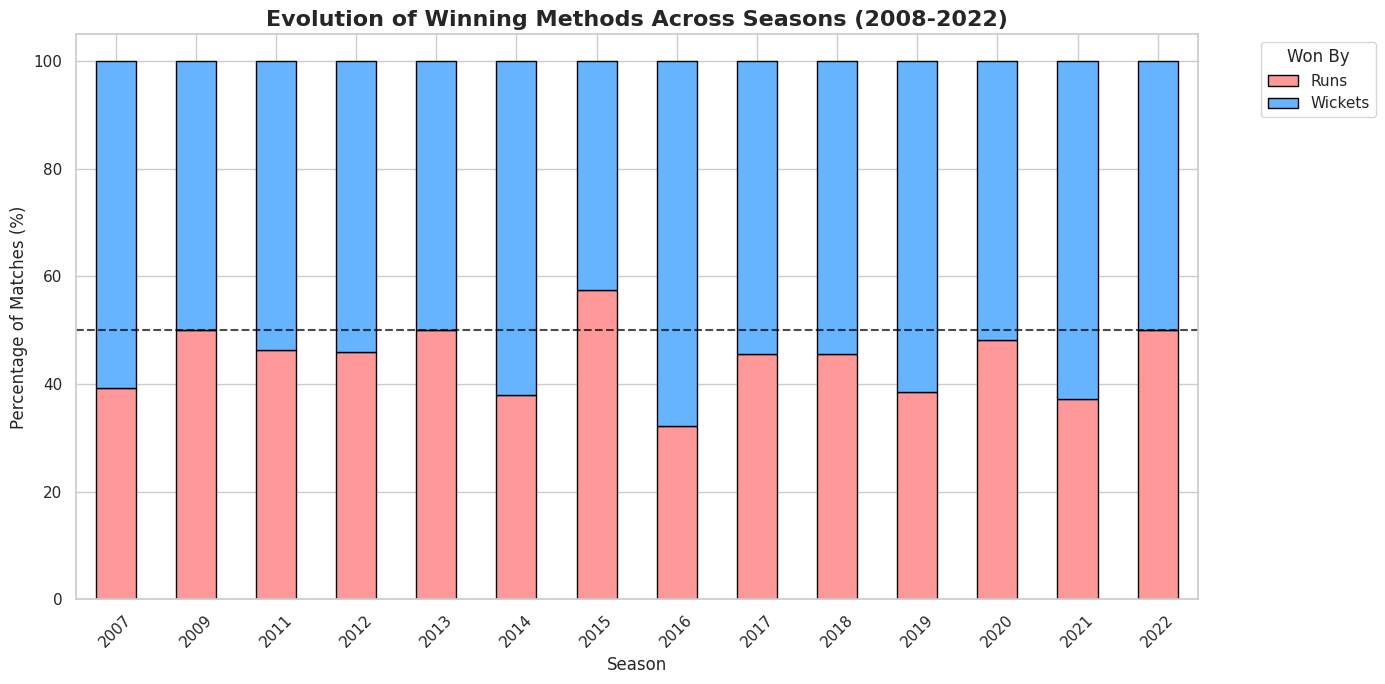

In [6]:
# we will use the previously imported seaborn as sns import for the stacked bar chart drawing

# We will first group data by Season and WonBy to get counts
season_trends = clean_df.groupby(['Season', 'WonBy']).size().unstack(fill_value=0)

# We will then convert counts to percentages for a 100% stacked bar chart
season_trends_pct = season_trends.div(season_trends.sum(axis=1), axis=0) * 100

# Stacked bar chart plotting
ax = season_trends_pct.plot(kind='bar', stacked=True, figsize=(14, 7),
                            color=['#FF9999', '#66B3FF'], edgecolor='black')

plt.title('Evolution of Winning Methods Across Seasons (2008-2022)', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Percentage of Matches (%)', fontsize=12)
plt.legend(title='Won By', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# We will also add a horizontal line at 50% to easily spot which method dominated each year
plt.axhline(50, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Since winning by "Runs" and winning by "Wickets" are measured on completely different scales, we cannot combine them into a single graph.

We have to split the dataset and look at them side by side to see if the margins are decreasing over time

(which indicates matches are getting more competitive)

We will draw boxplots for this analysis.

Our aim is now to find the margin of victory (It will determine competitiveness)

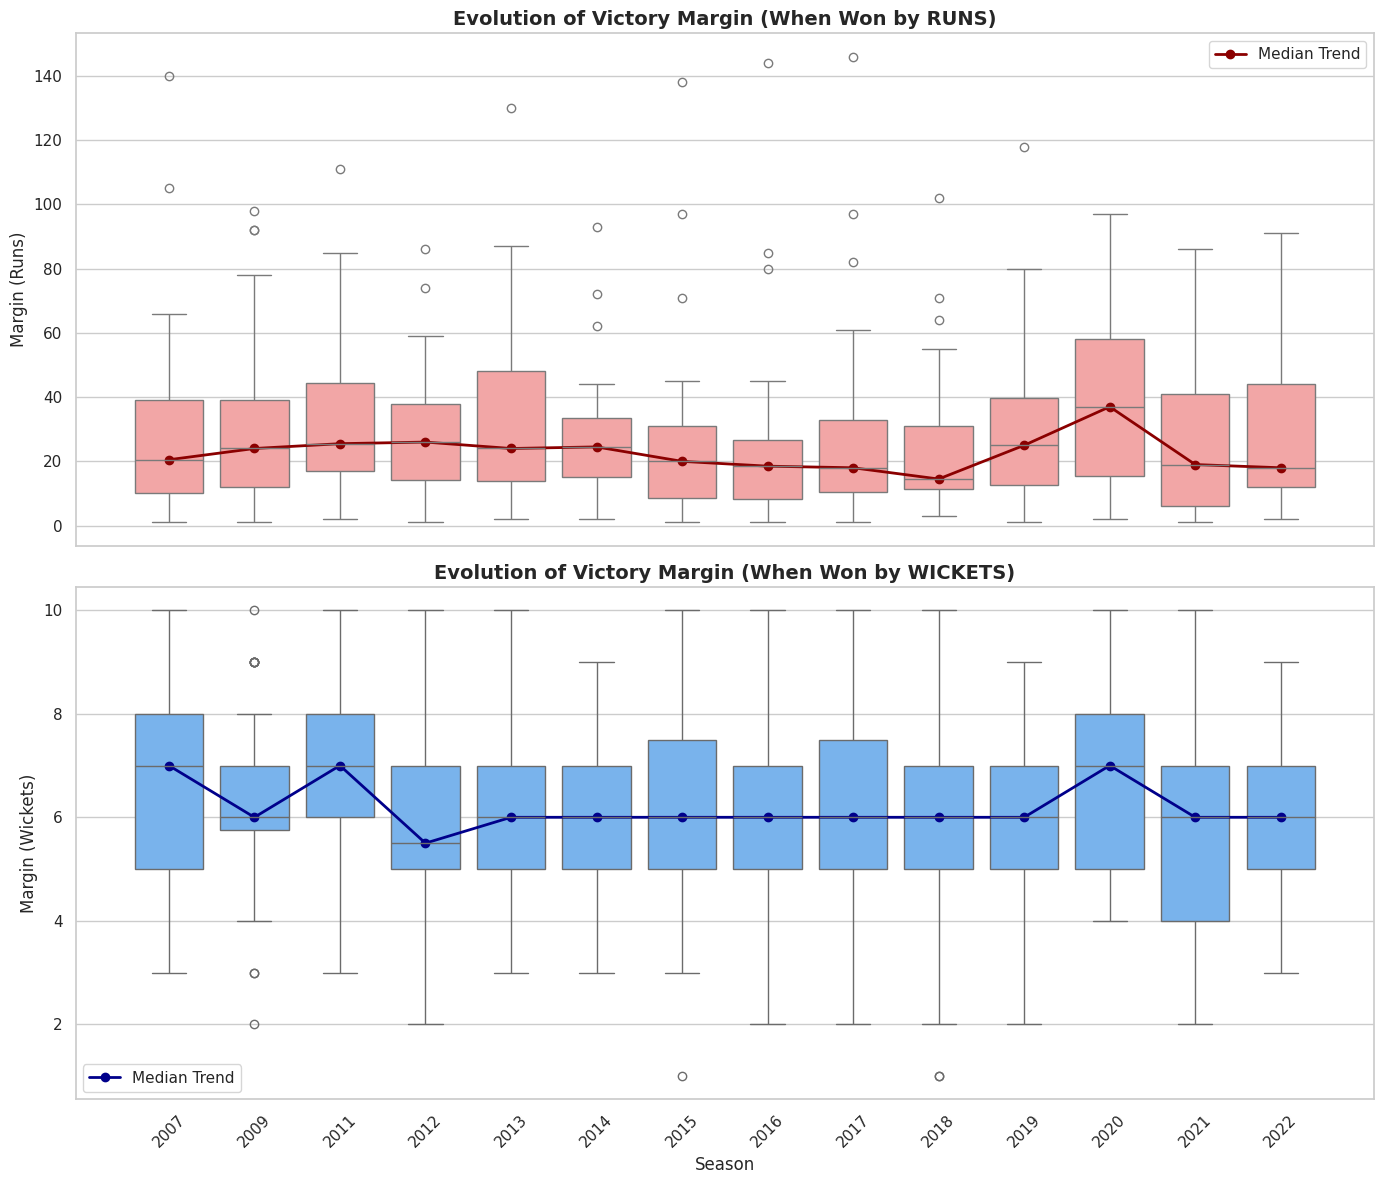

In [7]:
# We will first split the dataset based on the winning method
df_runs = clean_df[clean_df['WonBy'] == 'Runs']
df_wickets = clean_df[clean_df['WonBy'] == 'Wickets']

# We will then set up a figure with two subplots one above the other
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# We will then boxplot for (Margin of Victory by RUNS)
sns.boxplot(x='Season', y='Margin', data=df_runs, ax=axes[0], color='#FF9999')
axes[0].set_title('Evolution of Victory Margin (When Won by RUNS)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Margin (Runs)', fontsize=12)

# We will then add a line connecting the medians to easily spot the trend
medians_runs = df_runs.groupby('Season')['Margin'].median()
axes[0].plot(range(len(medians_runs)), medians_runs.values, color='darkred', marker='o', linestyle='-', linewidth=2, label='Median Trend')
axes[0].legend()

# We will then boxplot for (Margin of Victory by WICKETS)
sns.boxplot(x='Season', y='Margin', data=df_wickets, ax=axes[1], color='#66B3FF')
axes[1].set_title('Evolution of Victory Margin (When Won by WICKETS)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Margin (Wickets)', fontsize=12)
axes[1].set_xlabel('Season', fontsize=12)

# Then we will add a line connecting the medians for wickets
medians_wickets = df_wickets.groupby('Season')['Margin'].median()
axes[1].plot(range(len(medians_wickets)), medians_wickets.values, color='darkblue', marker='o', linestyle='-', linewidth=2, label='Median Trend')
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Now we will figure out why these trends are happening.

A massive part of T20 strategy happens at the coin toss.

We will check if captains historically preferred to bat first or field first and how that has evolved.

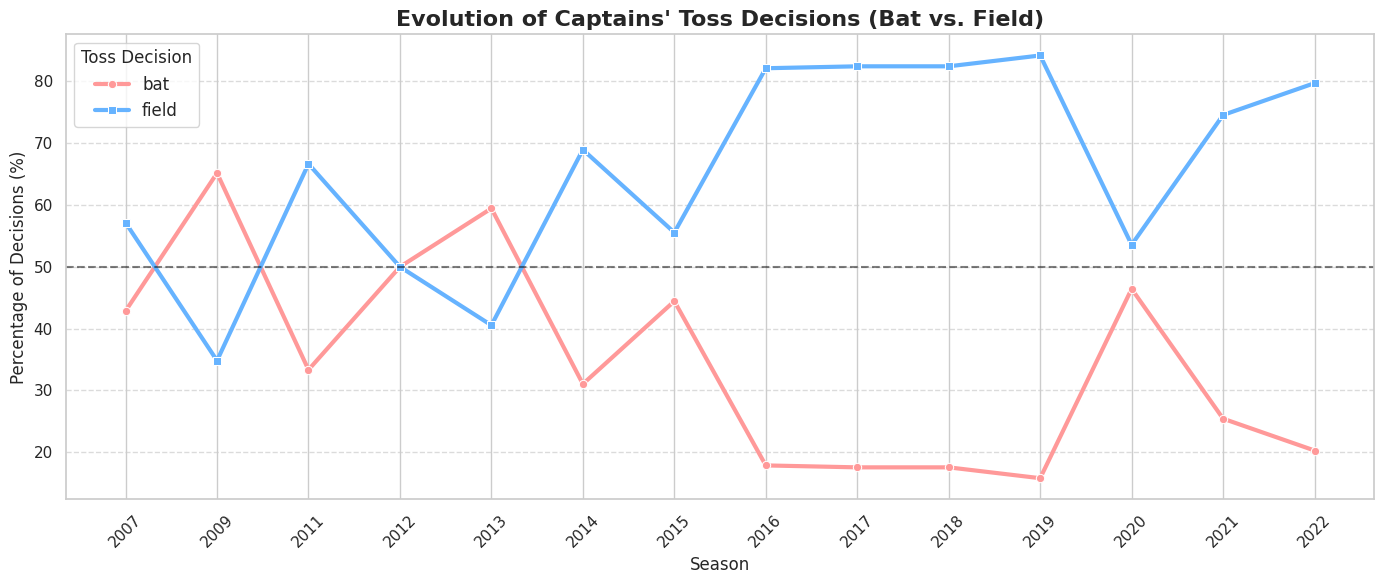

In [8]:
# We will first group data by Season and TossDecision
toss_trend = clean_df.groupby(['Season', 'TossDecision']).size().unstack(fill_value=0)

# Then we will convert data to percentages
toss_trend_pct = toss_trend.div(toss_trend.sum(axis=1), axis=0) * 100

# Then we will draw the trend
plt.figure(figsize=(14, 6))
sns.lineplot(data=toss_trend_pct, markers=['o', 's'], linewidth=3, dashes=False, palette=['#FF9999', '#66B3FF'])

plt.title('Evolution of Captains\' Toss Decisions (Bat vs. Field)', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Percentage of Decisions (%)', fontsize=12)
plt.legend(title='Toss Decision', fontsize=12)
plt.xticks(rotation=45)

# We will add a 50% baseline for visual reference
plt.axhline(50, color='black', linestyle='--', alpha=0.5)

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()